In [1]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

# from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error

sys.path.append("..")
import gpder
from gpder import plot_gpr
from gpder import SKGaussianProcessRegressor

In [2]:
def F(X, s=0.01):
    noise = s * np.random.uniform(-1, 1, X.shape[0])
    return X * np.sin(4*np.pi * X**2) + s

def dF(X, s=0.01):
    noise = s * np.random.uniform(-1, 1, X.shape[0])
    return np.sin(4*np.pi * X**2) + X * np.cos(4*np.pi * X**2) * (8*np.pi * X) + s

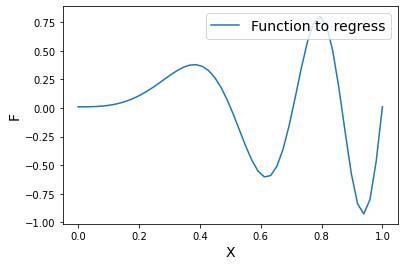

In [3]:
X_lower = 0
X_upper = 1
# X_lower = -5
# X_upper = 5
X_star = np.linspace(X_lower, X_upper, 50)
y_star = F(X_star)

plt.plot(X_star, y_star, label='Function to regress')
plt.xlabel("X", fontsize=14)
plt.ylabel("F", fontsize=14)
plt.legend(fontsize=14, loc='upper right')
plt.show()

In [4]:
np.random.seed(123)
X_train = np.random.uniform(X_lower, X_upper, 5)
y_train = F(X_train)

### SKlearn

Mean error :  0.14003606423561343


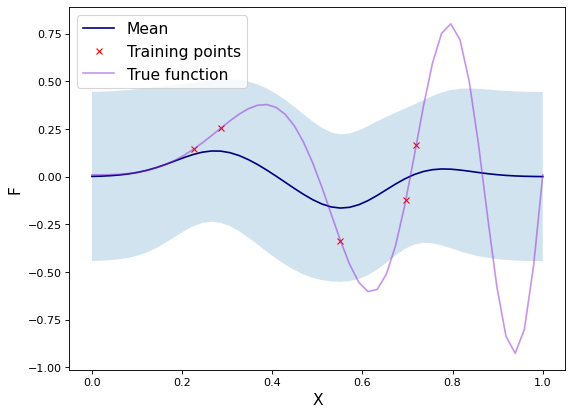

In [5]:
#K = ConstantKernel(1, 'fixed')*RBF(1, 'fixed') + WhiteKernel(1, 'fixed')
K = ConstantKernel()*RBF() + WhiteKernel()
gpr = SKGaussianProcessRegressor(kernel=K, 
                               #optimizer=None,
                               n_restarts_optimizer=10,
                               random_state=123)
gpr.fit(X_train.reshape(-1, 1), y_train)

mu, cov = gpr.predict(X_star.reshape(-1, 1), return_cov=True)
_, std = gpr.predict(X_star.reshape(-1, 1), return_std=True)
mu = mu.ravel()

mean_err_reg = mean_squared_error(y_star, mu)
print("Mean error : ", mean_err_reg)

nsamples = 1
samples = np.random.multivariate_normal(mu, cov, nsamples)
samples = []

plot_gpr(X_train=X_train, y_train=y_train, dX_train=[], dy_train=[],
         X_star=X_star, mu_star=mu, 
         std_star=std, samples=samples, F=F)

### Mine

In [6]:
from gpder import GPKernelDerAware, GPKernel
from gpder import GaussianProcessRegressor as Mine

Mean error :  0.14003604702250722


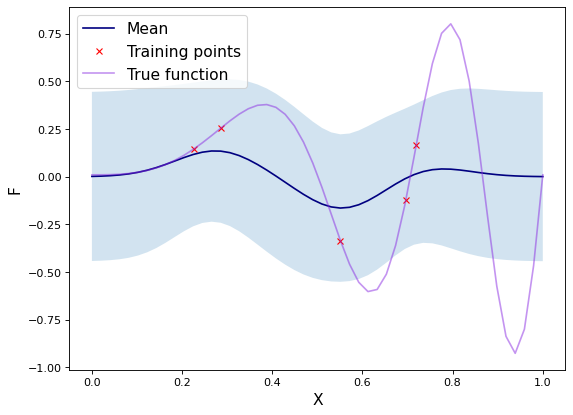

In [7]:
K_mine = GPKernel()
my_gpr = Mine(kernel=K_mine, 
              #optimizer=None,
              n_restarts_optimizer=10,
              random_state=123)
my_gpr.fit(X_train.reshape(-1, 1), y_train)

mu, cov = my_gpr.predict(X_star.reshape(-1, 1), return_cov=True)
_, std = my_gpr.predict(X_star.reshape(-1, 1), return_std=True)
mu = mu.ravel()

my_mean_err_reg = mean_squared_error(y_star, mu)
print("Mean error : ", my_mean_err_reg)

nsamples = 1
samples = np.random.multivariate_normal(mu, cov, nsamples)
samples = []

plot_gpr(X_train=X_train, y_train=y_train, dX_train=[], dy_train=[],
         X_star=X_star, mu_star=mu, 
         std_star=std, samples=samples, F=F)

In [8]:
print(mean_err_reg)
print(my_mean_err_reg)

0.14003606423561343
0.14003604702250722


Using the same optimization as SKlearn, I get a slightly different error: 0.14080996298237416
which doesn't converge.

Using my chain-rule optimization, I get a sligtly lower error: 0.14080024185852447
which also doesn't converge.

### With derivatives

In [9]:
dX_train = X_train
dy_train = dF(dX_train)

Mean error :  0.1989353994054131


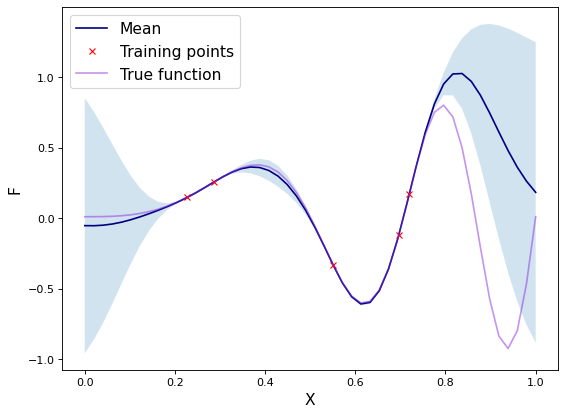

In [10]:
K_mine = GPKernelDerAware()
my_gpr = Mine(kernel=K_mine, 
              #optimizer=None,
              n_restarts_optimizer=10,
              random_state=123)
my_gpr.fit(X_train.reshape(-1, 1), y_train, dy_train)

mu, cov = my_gpr.predict(X_star.reshape(-1, 1), return_cov=True)
_, std = my_gpr.predict(X_star.reshape(-1, 1), return_std=True)
mu = mu.ravel()

my_mean_err_reg = mean_squared_error(y_star, mu)
print("Mean error : ", my_mean_err_reg)

nsamples = 1
samples = np.random.multivariate_normal(mu, cov, nsamples)
samples = []

plot_gpr(X_train=X_train, y_train=y_train, dX_train=[], dy_train=[],
         X_star=X_star, mu_star=mu, 
         std_star=std, samples=samples, F=F)